# **Data Loading**

In [1]:
# Import the required modules
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

# Load the data
data = fetch_california_housing(as_frame=True)
df = data.frame

# Display the data
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


# **Data Exploration**

In [2]:
print("Shape:", df.shape)

print("\nFeatures:", list(data.feature_names))

print("\nTarget:", data.target_names)

print("\nSummary Statistics:\n", df.describe().round(2))

print("\nDataset Info:\n", df.info)

print("Missing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

Shape: (20640, 9)

Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target: ['MedHouseVal']

Summary Statistics:
          MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  MedHouseVal  
count  20640.00   20640.00     20640.00  
mean      35.63    -119.57         2.07  
std        2.14       2.00         1.15  
min     

In [3]:
# Known quirk: the target was capped when the data was collected
n_capped = (df["MedHouseVal"] >= 5.0).sum()
print(f"Rows at target ceiling (5.0 = $500,001): {n_capped} ({n_capped/len(df)*100:.1f}%)")
print()

# Implausible derived values (these are per-household ratios)
for col, limit in [("AveRooms", 20), ("AveBedrms", 5), ("AveOccup", 10)]:
    n = (df[col] > limit).sum()
    print(f"  {col:11s} > {limit:2d}: {n:3d} rows  (max = {df[col].max():.1f})")

outliers = (df["AveRooms"] > 20) | (df["AveBedrms"] > 5) | (df["AveOccup"] > 10)
print(f"\nRows affected by any: {outliers.sum()} ({outliers.mean()*100:.1f}%)")

Rows at target ceiling (5.0 = $500,001): 992 (4.8%)

  AveRooms    > 20:  69 rows  (max = 141.9)
  AveBedrms   >  5:  45 rows  (max = 34.1)
  AveOccup    > 10:  37 rows  (max = 1243.3)

Rows affected by any: 108 (0.5%)


# **Data Splitting**

In [4]:
# Import the required module
from sklearn.model_selection import train_test_split

# Train-test split
X = df.drop(columns=["MedHouseVal"])
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (16512, 8)  Test: (4128, 8)


# **Linear Regression As A Baseline Model**

In [5]:
# Import the required modules
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate
def evaluate(name, model):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    print(f"{name:20s} RMSE={rmse:.4f}  MAE={mae:.4f}  R²={r2:.4f}")
    return {"model": name, "RMSE": rmse, "MAE": mae, "R2": r2}

# Linear regression needs scaling; trees do not
linreg = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
res_lin = evaluate("LinearRegression", linreg)

LinearRegression     RMSE=0.7456  MAE=0.5332  R²=0.5758


# **Random Forest**

In [6]:
# Import the required module
from sklearn.ensemble import RandomForestRegressor

# Train and evaulate the model
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
res_rf = evaluate("RandomForest", rf)

RandomForest         RMSE=0.5053  MAE=0.3275  R²=0.8051


# **XG Boost**

In [7]:
# Import the required module
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
res_xgb = evaluate("XGBoost", xgb)

XGBoost              RMSE=0.4626  MAE=0.3107  R²=0.8367


# **Comparison**

In [8]:
results = pd.DataFrame([res_lin, res_rf, res_xgb])
results["RMSE_vs_baseline_%"] = ((results["RMSE"] - res_lin["RMSE"]) / res_lin["RMSE"] * 100).round(1)
print(results.round(4).to_string(index=False))

           model   RMSE    MAE     R2  RMSE_vs_baseline_%
LinearRegression 0.7456 0.5332 0.5758                 0.0
    RandomForest 0.5053 0.3275 0.8051               -32.2
         XGBoost 0.4626 0.3107 0.8367               -37.9


# **Feature Importance**

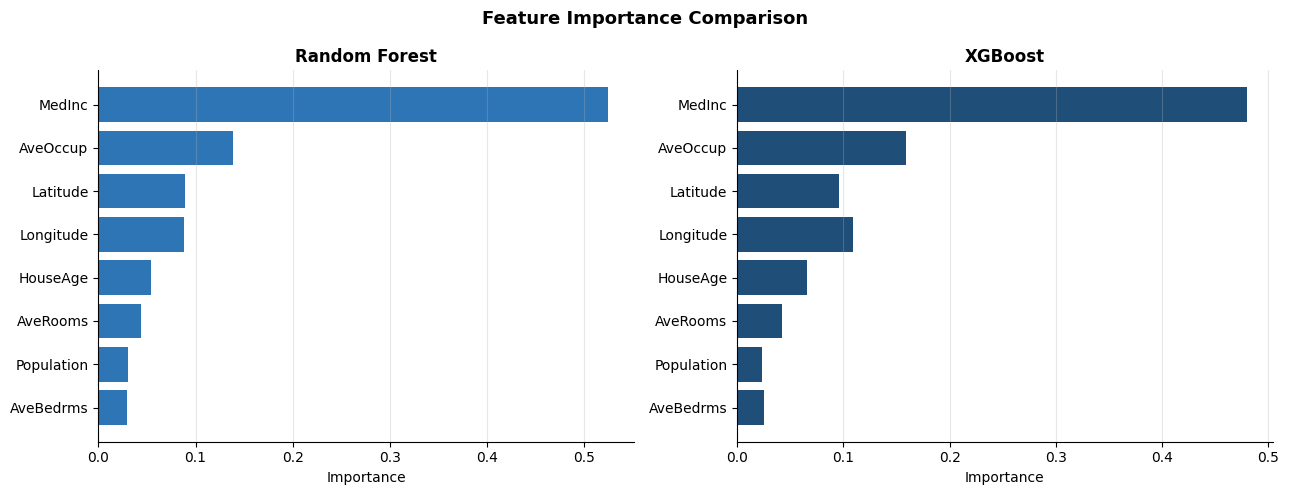

   feature  RandomForest  XGBoost  RF_rank  XGB_rank
    MedInc        0.5249   0.4799        1         1
  AveOccup        0.1384   0.1586        2         2
  Latitude        0.0889   0.0962        3         4
 Longitude        0.0886   0.1088        4         3
  HouseAge        0.0546   0.0656        5         5
  AveRooms        0.0443   0.0426        6         6
Population        0.0306   0.0233        7         8
 AveBedrms        0.0296   0.0251        8         7


In [9]:
import matplotlib.pyplot as plt

imp = pd.DataFrame({
    "feature": X.columns,
    "RandomForest": rf.feature_importances_,
    "XGBoost": xgb.feature_importances_,
}).sort_values("RandomForest")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].barh(imp["feature"], imp["RandomForest"], color="#2E75B6")
ax[0].set_title("Random Forest", fontweight="bold"); ax[0].set_xlabel("Importance")
ax[1].barh(imp["feature"], imp["XGBoost"], color="#1F4E79")
ax[1].set_title("XGBoost", fontweight="bold"); ax[1].set_xlabel("Importance")
for a in ax:
    a.spines[["top", "right"]].set_visible(False); a.grid(axis="x", alpha=0.3)
plt.suptitle("Feature Importance Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=140)
plt.show()

# Ranked table for the comparison
imp["RF_rank"]  = imp["RandomForest"].rank(ascending=False).astype(int)
imp["XGB_rank"] = imp["XGBoost"].rank(ascending=False).astype(int)
print(imp.sort_values("RandomForest", ascending=False).round(4).to_string(index=False))

## **How Random Forest and XGBoost differ in combining models**

Random Forest uses **bagging**: it trains many deep decision trees *in parallel*, each on a
random bootstrap sample of the rows and a random subset of features at every split, then
averages all their predictions. Because the trees are built independently and never see each
other's mistakes, averaging them mainly reduces **variance**, as it smooths out the noise that
any single deep tree would overfit to.

XGBoost uses **boosting**: it builds shallow trees *sequentially*, and each new tree is trained
specifically to correct the errors left over by the trees before it, with every tree's
contribution shrunk by a learning rate. Because each round targets the current residuals,
boosting reduces **bias** as well as variance, which is why it usually edges out a forest on
structured data but it is also more sensitive to overfitting and needs its learning rate and
tree count tuned with more care.

# **Model Save**

In [10]:
import joblib
import xgboost, sklearn

# Retrain the winning model on ALL the data before saving.
# The reported metrics came from the 80/20 split; for deployment you want
# the model to have seen every row.
final_model = XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1)
final_model.fit(X, y)

# Bundle the model WITH its feature order and metadata.
# Saving the bare model is the classic mistake — the app then has to guess
# the column order, and getting it wrong is a silent failure mode.
bundle = {
    "model": final_model,
    "feature_names": list(X.columns),
    "metrics": {"RMSE": res_xgb["RMSE"], "MAE": res_xgb["MAE"], "R2": res_xgb["R2"]},
    "versions": {"xgboost": xgboost.__version__, "sklearn": sklearn.__version__},
}

joblib.dump(bundle, "xgb_california_housing.joblib")
print("Saved. Versions:", bundle["versions"])

Saved. Versions: {'xgboost': '3.3.0', 'sklearn': '1.6.1'}


# **Save Verification**

In [11]:
loaded = joblib.load("xgb_california_housing.joblib")

print("Feature order:", loaded["feature_names"])
print("Metrics:", loaded["metrics"])

# Predict on one real row, passing a DataFrame with named columns
sample = X.iloc[[0]]
print("\nSample prediction:", round(float(loaded["model"].predict(sample)[0]), 4))
print("Actual value:      ", round(float(y.iloc[0]), 4))

# Confirm reload is identical to the in-memory model
assert np.allclose(final_model.predict(X[:100]), loaded["model"].predict(X[:100]))
print("\nReload verified — predictions identical.")

Feature order: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Metrics: {'RMSE': np.float64(0.46264842872316314), 'MAE': 0.31074241395526386, 'R2': 0.8366589575055071}

Sample prediction: 4.4565
Actual value:       4.526

Reload verified — predictions identical.


# **Widget Ranges For The App**

In [12]:
# 1st–99th percentiles make better slider bounds than min/max, because the true maxima are absurd outliers (AveOccup reaches 1,243)
print("Widget ranges for the Streamlit app:\n")
for c in X.columns:
    lo, hi = X[c].quantile([0.01, 0.99])
    print(f"  {c:11s} min={lo:9.3f}  max={hi:9.3f}  default={X[c].median():9.3f}")

Widget ranges for the Streamlit app:

  MedInc      min=    1.070  max=   10.597  default=    3.535
  HouseAge    min=    4.000  max=   52.000  default=   29.000
  AveRooms    min=    2.581  max=   10.357  default=    5.229
  AveBedrms   min=    0.873  max=    2.128  default=    1.049
  Population  min=   88.000  max= 5805.830  default= 1166.000
  AveOccup    min=    1.537  max=    5.395  default=    2.818
  Latitude    min=   32.680  max=   40.626  default=   34.260
  Longitude   min= -123.220  max= -116.290  default= -118.490
